--- DataFrame Head (First 5 Rows) ---
        Date     Price      Open      High       Low Vol.  Change %
0 2012-01-30  20731.72  20939.10  20950.02  20731.72  NaN   -0.0077
1 2012-01-31  20875.83  20818.56  21009.92  20789.48  NaN    0.0070
2 2012-02-01  20790.88  20875.34  20941.03  20790.88  NaN   -0.0041
3 2012-02-02  20822.00  20872.94  20900.58  20785.40  NaN    0.0015
4 2012-02-03  20877.64  20822.00  20863.93  20786.35  NaN    0.0027
--------------------------------------------------


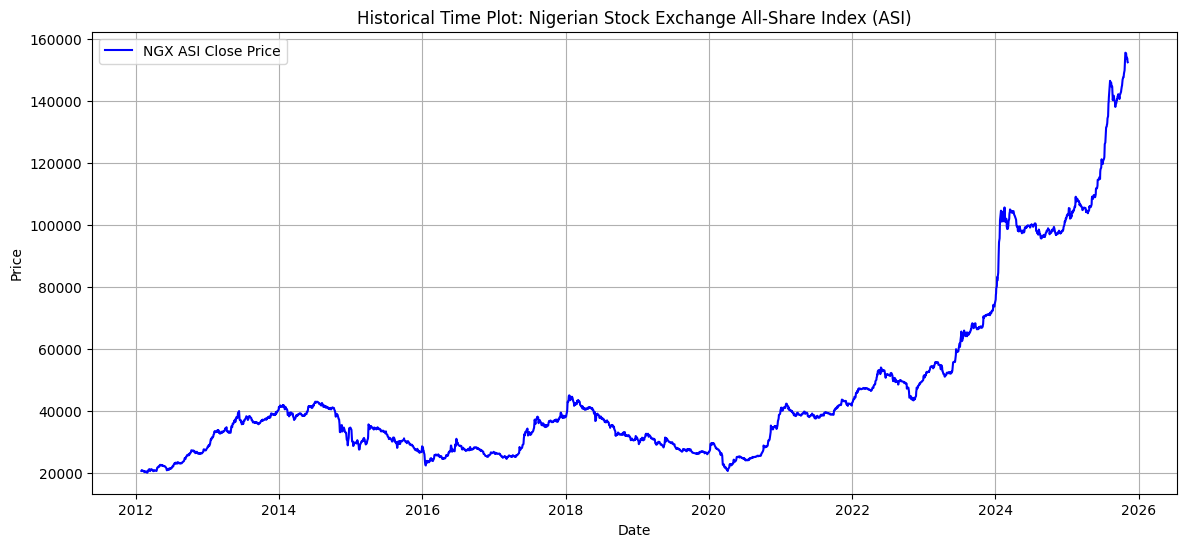

Total records: 3408
Training set size: 2726
Testing set size: 682

--- Array Heads (Step 1) ---
train_data (first 5): [20731.72 20875.83 20790.88 20822.   20877.64]
test_data (first 5):  [53499.68 53998.12 54213.09 54367.74 54299.76]


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#Data Loading & Preprocessing

# Load the data
df = pd.read_csv(r"C:\Users\ADMIN\Documents\NSE ASI DATA\NSE All Share Historical Data 30 JAN 2012 - 5 NOV 2025.csv")

# Converting 'Date'
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)

print("--- DataFrame Head (First 5 Rows) ---")
print(df.head())
print("-" * 50)

#Drawing the Time Plot of the Original Data 
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Price'], color='blue', label='NGX ASI Close Price')
plt.title('Historical Time Plot: Nigerian Stock Exchange All-Share Index (ASI)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.legend()
plt.show()

# Extracting the target variable (Price)
asi_data = df['Price'].values

# Splitting data into Training (80%) and Testing (20%)
train_size = int(len(asi_data) * 0.8)
train_data, test_data = asi_data[:train_size], asi_data[train_size:]

print("Total records:", len(asi_data))
print("Training set size:", len(train_data))
print("Testing set size:", len(test_data))
print("\n--- Array Heads (Step 1) ---")
print(f"train_data (first 5): {train_data[:5]}")
print(f"test_data (first 5):  {test_data[:5]}")

--- ADF Test: Original Training Data ---
Test Statistic: -0.9538
p-value: 0.7697
Conclusion: Fail to reject. The series is NON-STATIONARY.

Applying 1st Order Differencing to achieve stationarity...
--- ADF Test: 1st Order Differenced Data ---
Test Statistic: -22.5218
p-value: 0.0000
Conclusion: Reject the null hypothesis. The series is STATIONARY.



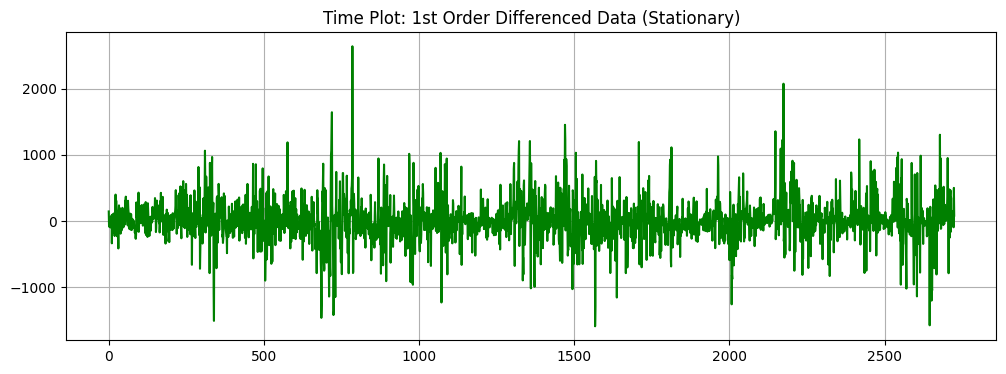

In [2]:
# Testing for Stationarity & Differencing

from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries, title):
    print(f'--- ADF Test: {title} ---')
    adf_test = adfuller(timeseries, autolag='AIC')
    p_value = adf_test[1]
    
    print(f"Test Statistic: {adf_test[0]:.4f}")
    print(f"p-value: {p_value:.4f}")
    
    if p_value <= 0.05:
        print("Conclusion: Reject the null hypothesis. The series is STATIONARY.\n")
        return True
    else:
        print("Conclusion: Fail to reject. The series is NON-STATIONARY.\n")
        return False

# Testing the original training data
is_stationary = test_stationarity(train_data, "Original Training Data")

# If not stationary, apply 1st Order Differencing and test again
if not is_stationary:
    print("Applying 1st Order Differencing to achieve stationarity...")
    # Calculate the difference between today's price and yesterday's price
    train_data_diff = pd.Series(train_data).diff().dropna().values
    
    # Test the differenced data
    test_stationarity(train_data_diff, "1st Order Differenced Data")
    
    # Plot the difference to show it looks like stationary "white noise"
    plt.figure(figsize=(12,4))
    plt.plot(train_data_diff, color='green')
    plt.title("Time Plot: 1st Order Differenced Data (Stationary)")
    plt.grid(True)
    plt.show()

--- Testing for Seasonality ---


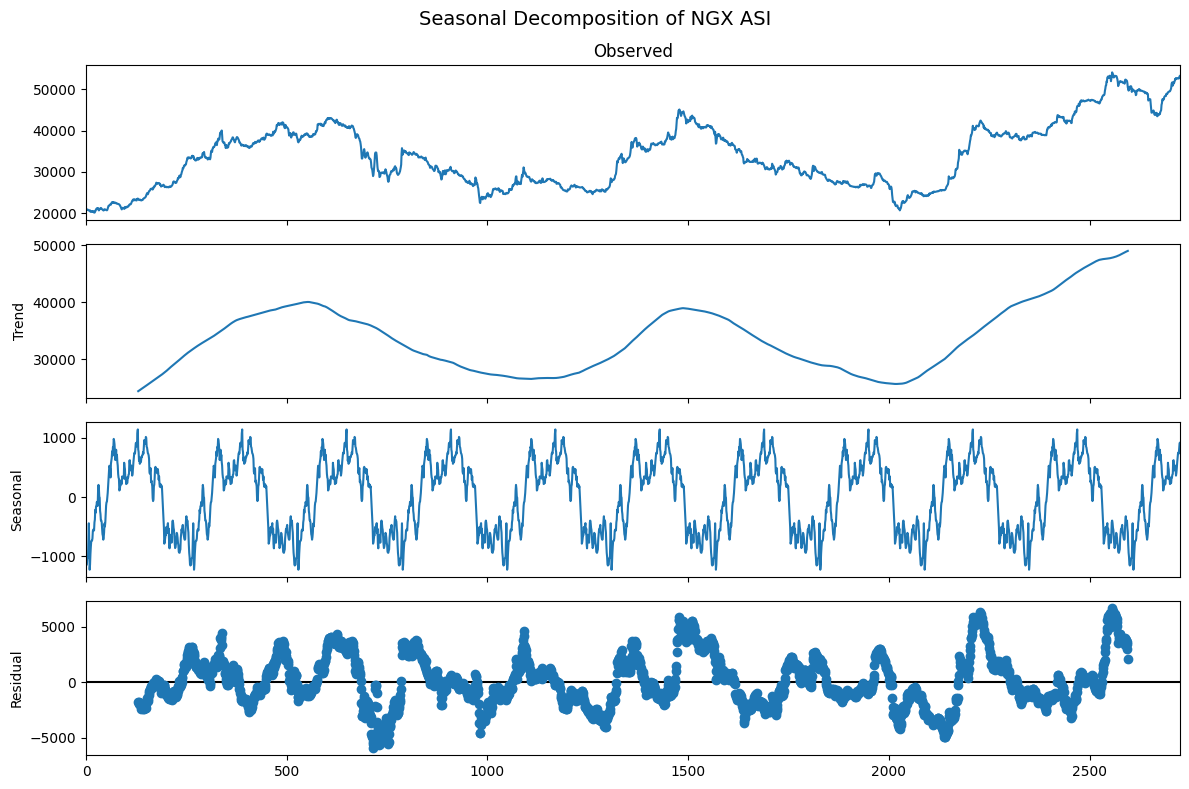

Variance of Seasonal Component: 370731.6035
the variance > 0 and the plot shows a repeating wave, SEASONALITY IS PRESENT.
--------------------------------------------------


In [3]:
# Testing for Seasonality
from statsmodels.tsa.seasonal import seasonal_decompose
print("--- Testing for Seasonality ---")
# We decompose the series to see Trend, Seasonality, and Residuals separately.
decomposition = seasonal_decompose(train_data, model='additive', period=260)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Seasonal Decomposition of NGX ASI", fontsize=14)
plt.tight_layout()
plt.show()

# Extract the seasonal component to prove it exists
seasonal_component = decomposition.seasonal
print(f"Variance of Seasonal Component: {np.var(seasonal_component):.4f}")
print("the variance > 0 and the plot shows a repeating wave, SEASONALITY IS PRESENT.")
print("-" * 50)

In [4]:

# SARIMA Modeling With Walk-Forward 
import pmdarima as pm
print("Training SARIMA Model...")
sarima_model = pm.auto_arima(
    train_data, 
    d=1,                
    seasonal=True, m=5, 
    trace=True, error_action='ignore', suppress_warnings=True, stepwise=True
)

print(sarima_model.summary())

# Generating predictions for the training set (in-sample)
train_linear_predictions = sarima_model.predict_in_sample()

# Rolling Forecast for Test Set
print("Generating rolling 1-step-ahead forecasts for the test set")
test_linear_predictions = []

# Looping through the test set one day at a time
for i in range(len(test_data)):
    # Predict exactly 1 day into the future
    pred = sarima_model.predict(n_periods=1)
    
    # Extract the value safely (handles both pandas Series and numpy arrays)
    pred_value = pred.iloc[0] if isinstance(pred, pd.Series) else pred[0]
    test_linear_predictions.append(pred_value)
    
    # Reveal the actual market price to the model so it can adjust for the next day
    sarima_model.update(test_data[i])

test_linear_predictions = np.array(test_linear_predictions)

Training SARIMA Model...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[5] intercept   : AIC=38992.454, Time=13.33 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=39204.536, Time=0.16 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=38989.579, Time=0.76 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=39009.935, Time=0.84 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=39206.279, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[5] intercept   : AIC=38992.078, Time=0.55 sec
 ARIMA(1,1,0)(2,0,0)[5] intercept   : AIC=38990.725, Time=1.46 sec
 ARIMA(1,1,0)(1,0,1)[5] intercept   : AIC=38991.205, Time=3.08 sec
 ARIMA(1,1,0)(0,0,1)[5] intercept   : AIC=38989.732, Time=1.19 sec
 ARIMA(1,1,0)(2,0,1)[5] intercept   : AIC=38992.723, Time=1.69 sec
 ARIMA(0,1,0)(1,0,0)[5] intercept   : AIC=39199.737, Time=0.50 sec
 ARIMA(2,1,0)(1,0,0)[5] intercept   : AIC=38991.063, Time=0.93 sec
 ARIMA(1,1,1)(1,0,0)[5] intercept   : AIC=38991.104, Time=1.54 sec
 ARIMA(0,1,1)(1,0,0)[5] intercept   : AIC=39009.735, Time=0.

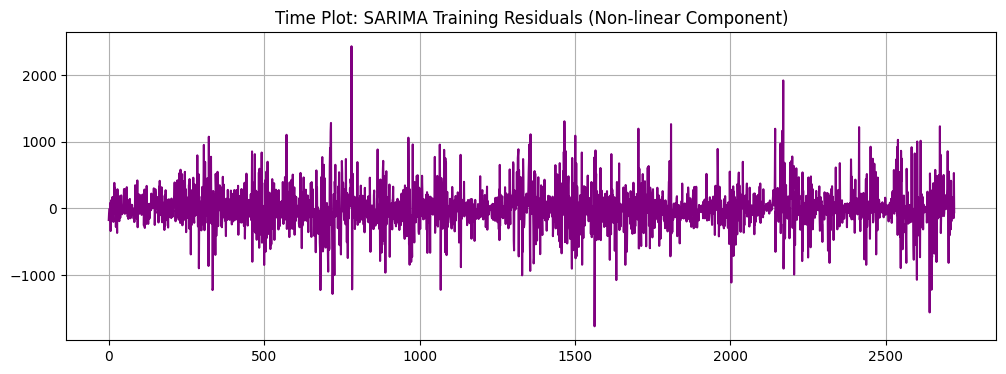

In [5]:
# Residual Extraction (Errors)

train_residuals = train_data - train_linear_predictions
test_residuals = test_data - test_linear_predictions
# Drop the first 5 days of startup artifacts 
# We only need to trim the training data because the model is already 
# warmed up by the time it reaches the test data.

warmup = 5
train_residuals_clean = train_residuals[warmup:]

plt.figure(figsize=(12,4))
plt.plot(train_residuals_clean, color='purple')
plt.title('Time Plot: SARIMA Training Residuals (Non-linear Component)')
plt.grid(True)
plt.show()

In [13]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, SimpleRNN, LSTM, GRU

In [18]:
# SEED SETTING FOR REPRODUCIBILITY

import os
import random
import numpy as np
import tensorflow as tf

seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

# Scale the cleaned residuals
scaler = MinMaxScaler(feature_range=(-1, 1))
train_res_scaled = scaler.fit_transform(train_residuals_clean.reshape(-1, 1))
test_res_scaled = scaler.transform(test_residuals.reshape(-1, 1))

# Sequence Generator Function
def create_sequences(input_data, time_steps=10):
    X, Y = [], []
    for i in range(len(input_data) - time_steps):
        X.append(input_data[i:(i + time_steps), 0])
        Y.append(input_data[i + time_steps, 0])
    return np.array(X), np.array(Y)

time_steps = 10
X_train, Y_train = create_sequences(train_res_scaled, time_steps)
X_test, Y_test = create_sequences(test_res_scaled, time_steps)

# Reshape for Deep Learning [samples, time_steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Dynamic Architecture Builder
def build_dl_model(model_type):
    model = Sequential()
    model.add(Input(shape=(time_steps, 1)))
    
    if model_type == 'RNN':
        model.add(SimpleRNN(50, return_sequences=True))
        model.add(Dropout(0.2))
        model.add(SimpleRNN(50, return_sequences=False))
    elif model_type == 'LSTM':
        model.add(LSTM(50, return_sequences=True))
        model.add(Dropout(0.2))
        model.add(LSTM(50, return_sequences=False))
    elif model_type == 'GRU':
        model.add(GRU(50, return_sequences=True))
        model.add(Dropout(0.2))
        model.add(GRU(50, return_sequences=False))
        
    model.add(Dropout(0.2))
    model.add(Dense(1)) 
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Custom Evaluation Functions
def calculate_smape(actual, predicted):
    return 100/len(actual) * np.sum(2 * np.abs(predicted - actual) / (np.abs(actual) + np.abs(predicted)))

def calculate_mase(actual, predicted, training_data):
    n = len(training_data)
    naive_error = np.abs(np.diff(training_data)).sum() / (n - 1)
    mae = mean_absolute_error(actual, predicted)
    return mae / naive_error

def evaluate_all_metrics(actual, predicted, training_data, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = mean_absolute_percentage_error(actual, predicted) * 100 
    smape = calculate_smape(actual, predicted)
    mase = calculate_mase(actual, predicted, training_data)
    
    # THESE PRINT STATEMENTS OUTPUT THE FINAL NUMBERS TO YOUR SCREEN
    print(f"--- {model_name} Residual Performance ---")
    print(f"MAE:   {mae:.4f}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"MAPE:  {mape:.4f}%")
    print(f"SMAPE: {smape:.4f}%")
    print(f"MASE:  {mase:.4f}")
    print("-" * 45)

# 5. Train all three models and print metrics immediately
dl_architectures = ['RNN', 'LSTM', 'GRU']
dl_predictions = {}
aligned_actual_residuals = test_residuals[time_steps:]

# Variables to track the champion model
lowest_rmse = float('inf')
best_model_name = ""

for arch in dl_architectures:
    print(f"\n>> Training {arch} Model...")
    model = build_dl_model(arch)
    
    # Fit the model
    model.fit(X_train, Y_train, epochs=50, batch_size=32, validation_data=(X_test, Y_test), verbose=0) 
    
    # Generate predictions and un-scale them
    preds_scaled = model.predict(X_test, verbose=0)
    preds = scaler.inverse_transform(preds_scaled).flatten()
    dl_predictions[arch] = preds
    
    # Print the evaluation metrics 
    evaluate_all_metrics(aligned_actual_residuals, preds, train_residuals_clean, arch)
    
    # Check if this model is the new winner
    current_rmse = np.sqrt(mean_squared_error(aligned_actual_residuals, preds))
    if current_rmse < lowest_rmse:
        lowest_rmse = current_rmse
        best_model_name = arch

print(f"\n CHAMPION MODEL : {best_model_name} (Lowest Residual RMSE)")


>> Training RNN Model...
--- RNN Residual Performance ---
MAE:   435.4096
RMSE:  655.5666
MAPE:  102.6420%
SMAPE: 177.1010%
MASE:  1.4394
---------------------------------------------

>> Training LSTM Model...
--- LSTM Residual Performance ---
MAE:   435.6112
RMSE:  655.9839
MAPE:  101.8182%
SMAPE: 177.1175%
MASE:  1.4400
---------------------------------------------

>> Training GRU Model...
--- GRU Residual Performance ---
MAE:   435.3671
RMSE:  655.6938
MAPE:  102.8130%
SMAPE: 175.0013%
MASE:  1.4392
---------------------------------------------

 CHAMPION MODEL : RNN (Lowest Residual RMSE)


--- Formulating Final Hybrid Model using RNN ---


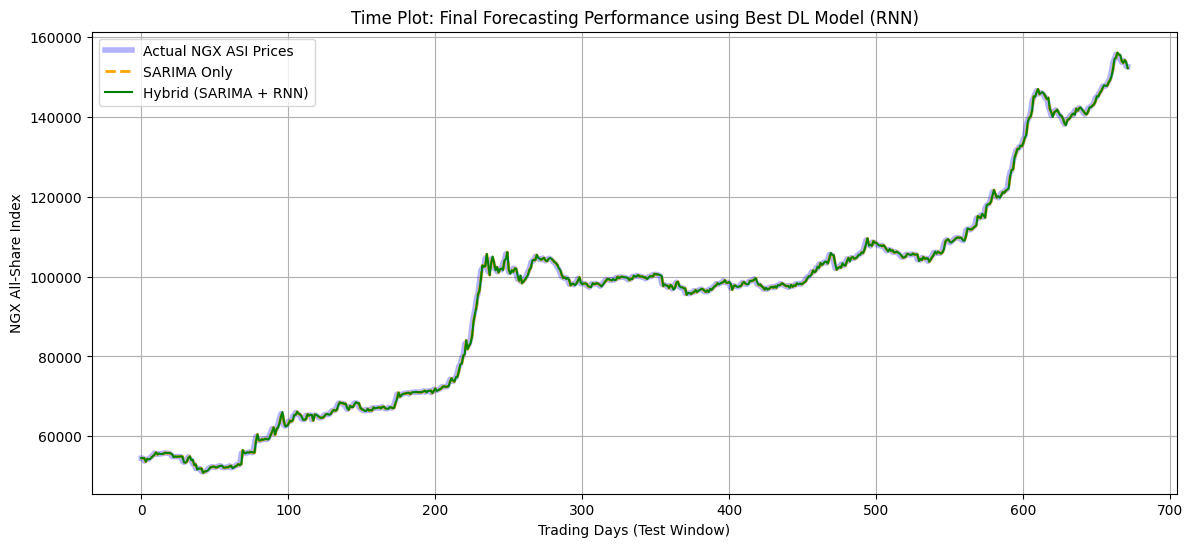

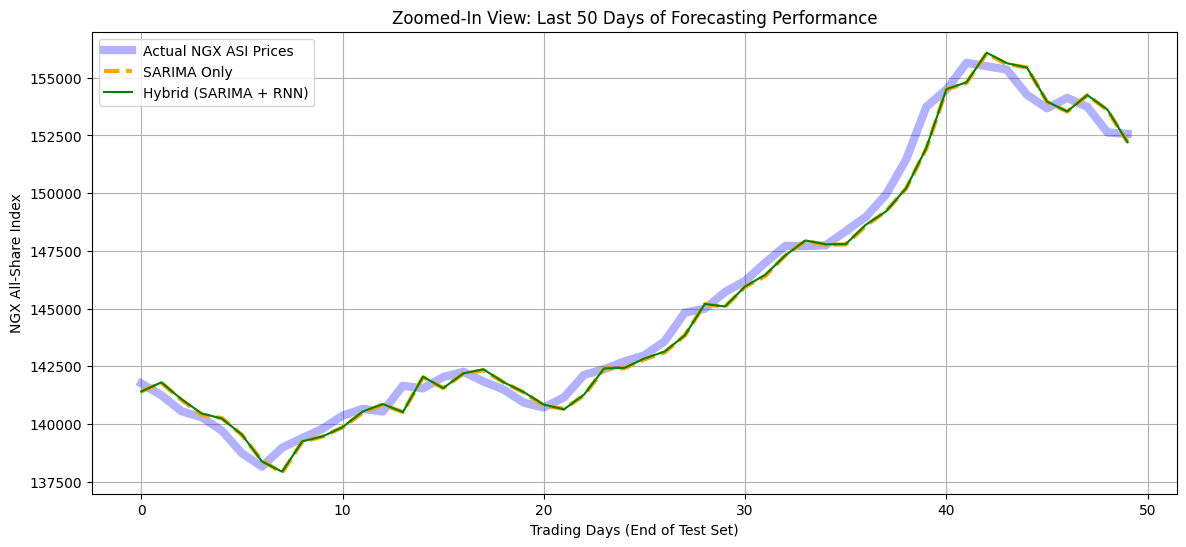

In [19]:
# Final Hybrid Forecast Formulation (CORRECTED)

import matplotlib.pyplot as plt

print(f"--- Formulating Final Hybrid Model using {best_model_name} ---")

# 1. Align arrays to match the time_steps used in the Deep Learning models
aligned_test_data = test_data[time_steps:]
aligned_linear_predictions = test_linear_predictions[time_steps:]

# 2. Fetching the winning model's predictions from the dictionary
best_predicted_residuals = dl_predictions[best_model_name]

# 3. Final Forecast = Linear (SARIMA) + Non-linear (THE BEST DL MODEL)
hybrid_predictions = aligned_linear_predictions + best_predicted_residuals


# VISUALIZATION 1: Full Test Set View

plt.figure(figsize=(14,6))
# Using thickness and transparency so all lines are visible
plt.plot(aligned_test_data, label='Actual NGX ASI Prices', color='blue', linewidth=4, alpha=0.3)
plt.plot(aligned_linear_predictions, label='SARIMA Only', color='orange', linestyle='--', linewidth=2)
plt.plot(hybrid_predictions, label=f'Hybrid (SARIMA + {best_model_name})', color='green', linewidth=1.5)

plt.title(f'Time Plot: Final Forecasting Performance using Best DL Model ({best_model_name})')
plt.xlabel('Trading Days (Test Window)')
plt.ylabel('NGX All-Share Index')
plt.legend()
plt.grid(True)
plt.show()


# VISUALIZATION 2: Zoomed-In View 

zoom_days = 50 # Look at just the last 50 trading days

plt.figure(figsize=(14,6))
plt.plot(aligned_test_data[-zoom_days:], label='Actual NGX ASI Prices', color='blue', linewidth=6, alpha=0.3)
plt.plot(aligned_linear_predictions[-zoom_days:], label='SARIMA Only', color='orange', linestyle='--', linewidth=3)
plt.plot(hybrid_predictions[-zoom_days:], label=f'Hybrid (SARIMA + {best_model_name})', color='green', linewidth=1.5)

plt.title(f'Zoomed-In View: Last 50 Days of Forecasting Performance')
plt.xlabel('Trading Days (End of Test Set)')
plt.ylabel('NGX All-Share Index')
plt.legend()
plt.grid(True)
plt.show()

In [20]:

# COMPREHENSIVE MODEL EVALUATION 

print("FINAL MODEL EVALUATION")

# Generate Standalone Deep Learning Predictions
print(f"Training Standalone {best_model_name} on raw prices for accurate comparison...\n")

# Scale the raw prices
scaler_raw = MinMaxScaler(feature_range=(-1, 1))
train_raw_scaled = scaler_raw.fit_transform(train_data.reshape(-1, 1))
test_raw_scaled = scaler_raw.transform(test_data.reshape(-1, 1))

# Generate sequences
X_train_raw, Y_train_raw = create_sequences(train_raw_scaled, time_steps)
X_test_raw, Y_test_raw = create_sequences(test_raw_scaled, time_steps)

# Reshape
X_train_raw = np.reshape(X_train_raw, (X_train_raw.shape[0], X_train_raw.shape[1], 1))
X_test_raw = np.reshape(X_test_raw, (X_test_raw.shape[0], X_test_raw.shape[1], 1))

# Build, train, and predict using the Champion architecture
standalone_dl = build_dl_model(best_model_name)
standalone_dl.fit(X_train_raw, Y_train_raw, epochs=50, batch_size=32, verbose=0)
standalone_preds_scaled = standalone_dl.predict(X_test_raw, verbose=0)
standalone_dl_predictions = scaler_raw.inverse_transform(standalone_preds_scaled).flatten()

#  Master Evaluation
evaluate_all_metrics(aligned_test_data, aligned_linear_predictions, train_data, "Standalone SARIMA Model")
evaluate_all_metrics(aligned_test_data, standalone_dl_predictions, train_data, f"Standalone {best_model_name} Model")
evaluate_all_metrics(aligned_test_data, hybrid_predictions, train_data, f"Hybrid (SARIMA + {best_model_name}) Model")

FINAL MODEL EVALUATION
Training Standalone RNN on raw prices for accurate comparison...

--- Standalone SARIMA Model Residual Performance ---
MAE:   437.6987
RMSE:  658.5097
MAPE:  0.4792%
SMAPE: 0.4799%
MASE:  2.0649
---------------------------------------------
--- Standalone RNN Model Residual Performance ---
MAE:   19907.9537
RMSE:  25496.5758
MAPE:  18.0491%
SMAPE: 20.6608%
MASE:  93.9169
---------------------------------------------
--- Hybrid (SARIMA + RNN) Model Residual Performance ---
MAE:   435.4096
RMSE:  655.5666
MAPE:  0.4767%
SMAPE: 0.4773%
MASE:  2.0541
---------------------------------------------


In [ ]:
# 